
# Generative Reservoir Computing (GRC): 2D Reservoir, Sliced Marginals, and Moment Matching (JAX)

This notebook builds a simple **pedagogical** example of:
1. Sampling a *complicated* 2D **reservoir** distribution via a nonlinear warp of a Gaussian mixture.
2. Computing and visualizing **sliced marginals** along different directions (unit vectors on the plane).
3. Performing **moment matching** by learning a cubic polynomial that maps a chosen 1D projection of the reservoir to match a **target** distribution's first four central moments.

> Theory background and notation align with your write-up on moment/feature matching readouts from a high-dimensional reservoir.

### What you'll get
- Clean figures to drop into a proposal: reservoir scatter, multiple 1D marginals, and **before/after** density comparisons for moment matching.
- All core computations are done with **JAX** (arrays + autodiff) and plain **matplotlib** for plotting (no seaborn, no styling).

> Tip: If you don't have GPU, this runs fine on CPU for the sizes used here.


In [1]:

# JAX + plotting
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# --- Lightweight 1D Gaussian KDE (no external deps) ---
def kde_1d(samples, grid, bandwidth=None):
    x = jnp.asarray(samples).reshape(-1, 1)
    g = jnp.asarray(grid).reshape(1, -1)
    n = x.shape[0]
    if bandwidth is None:
        std = jnp.std(samples)
        bw = 1.06 * std * (n ** (-1/5))
        bw = jnp.maximum(bw, 1e-6)
    else:
        bw = bandwidth
    z = (g - x) / bw
    phi = jnp.exp(-0.5 * z**2) / jnp.sqrt(2 * jnp.pi)
    dens = jnp.mean(phi, axis=0) / bw
    return dens


2025-10-15 00:03:10.741927: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


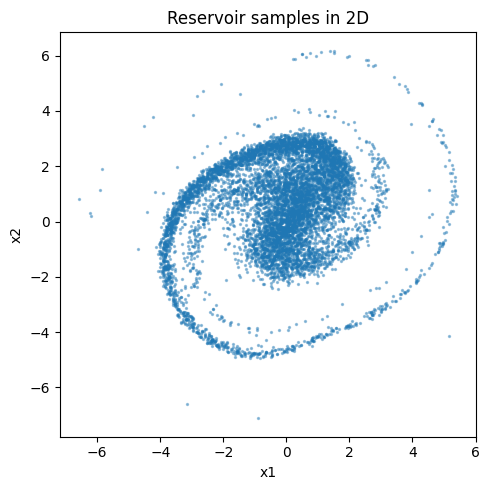

In [2]:

# -----------------------------
# 1) Build a "complicated" 2D reservoir distribution p_R(x)
#    via nonlinear warp of a Gaussian mixture
# -----------------------------
key = jax.random.PRNGKey(0)

def sample_reservoir(key, n=8000):
    keys = jax.random.split(key, 3)
    mean1 = jnp.array([0.0, 0.0])
    mean2 = jnp.array([2.5, -1.2])
    cov1 = jnp.array([[1.0, 0.8],[0.8, 1.5]])
    cov2 = jnp.array([[0.7, -0.4],[-0.4, 1.2]])
    L1 = jnp.linalg.cholesky(cov1)
    L2 = jnp.linalg.cholesky(cov2)
    z1 = jax.random.normal(keys[0], (n//2, 2)) @ L1.T + mean1
    z2 = jax.random.normal(keys[1], (n - n//2, 2)) @ L2.T + mean2
    z = jnp.vstack([z1, z2])
    # non-linear warp
    def warp(v):
        x, y = v[..., 0], v[..., 1]
        r2 = x**2 + y**2
        x_new = x * jnp.cos(0.25 * r2) - y * jnp.sin(0.25 * r2)
        y_new = x * jnp.sin(0.25 * r2) + y * jnp.cos(0.25 * r2)
        y_new = y_new + 0.75 * jnp.tanh(0.6 * x_new)
        return jnp.stack([x_new, y_new], axis=-1)
    return warp(z)

reservoir = sample_reservoir(key, n=8000)

plt.figure(figsize=(5,5))
plt.scatter(np.array(reservoir[:,0]), np.array(reservoir[:,1]), s=2, alpha=0.4)
plt.title("Reservoir samples in 2D"); plt.xlabel("x1"); plt.ylabel("x2"); plt.tight_layout(); plt.show()


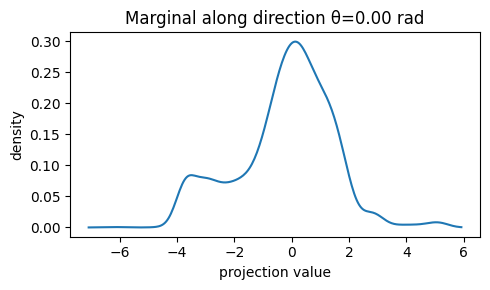

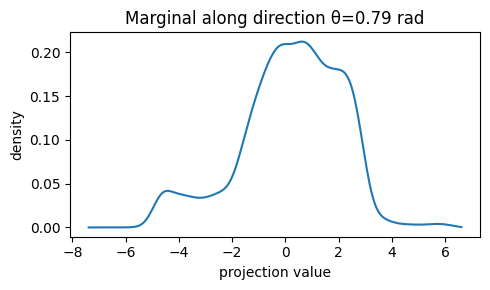

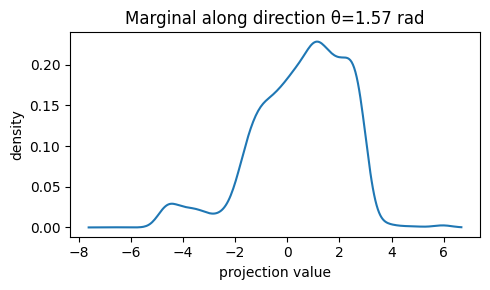

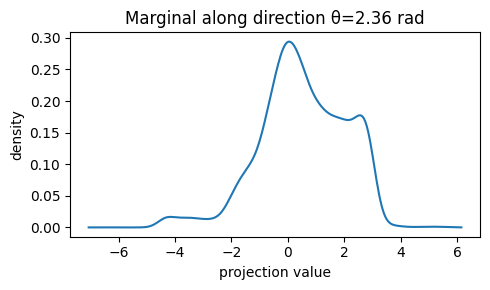

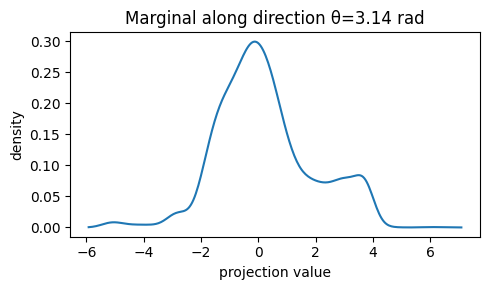

In [3]:

# -----------------------------
# 2) Sliced marginals: project along different directions u(theta)
# -----------------------------
def unit_vec(theta):
    return jnp.array([jnp.cos(theta), jnp.sin(theta)])

thetas = jnp.linspace(0.0, jnp.pi, 5)  # a few directions
dirs = jnp.stack([unit_vec(t) for t in thetas], axis=0)
projections = [reservoir @ d for d in dirs]

for t, s in zip(np.array(thetas), projections):
    plt.figure(figsize=(5,3))
    grid = jnp.linspace(jnp.min(s)-0.5, jnp.max(s)+0.5, 300)
    dens = kde_1d(s, grid)
    plt.plot(np.array(grid), np.array(dens))
    plt.title(f"Marginal along direction θ={float(t):.2f} rad")
    plt.xlabel("projection value"); plt.ylabel("density"); plt.tight_layout(); plt.show()


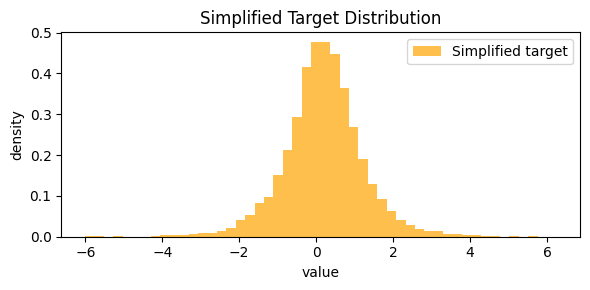

Target moments (μ, m2, m3, m4, m5, m6): 0.19354048 1.1033839 0.021308908 7.165376 -0.44911036 112.51549
Reservoir projection moments: 0.520803 3.1472013 -4.1026855 35.855667 -108.824524 726.6689
Step 0: loss = 1099046.750000, coeffs = [ 0.00612265  1.0112259   0.01137346 -0.0081284  -0.00889694  0.00121283]
Step 500: loss = 10.633739, coeffs = [ 6.0973782e-03  1.0110888e+00  1.1953542e-02 -9.0010893e-03
  2.1460699e-03 -6.4355443e-04]
Step 1000: loss = 7.568916, coeffs = [ 5.6915320e-03  1.0106112e+00  1.1388040e-02 -1.0878429e-02
  3.2055259e-03 -1.7547244e-04]
Step 1500: loss = 7.331997, coeffs = [ 5.30965440e-03  1.01017964e+00  1.07680317e-02 -1.25643946e-02
  3.20297899e-03 -1.20184544e-04]
Step 2000: loss = 7.137141, coeffs = [ 4.9801101e-03  1.0098071e+00  1.0225259e-02 -1.3982340e-02
  3.1960425e-03 -7.1738206e-05]
Step 2500: loss = 6.972400, coeffs = [ 4.6914229e-03  1.0094854e+00  9.7459033e-03 -1.5203005e-02
  3.1858033e-03 -2.8767994e-05]


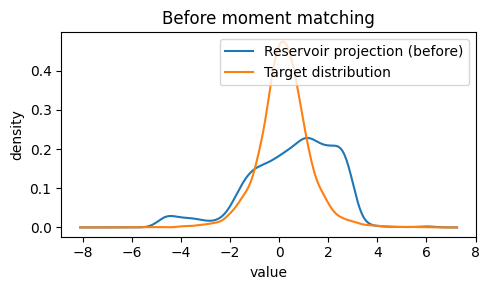

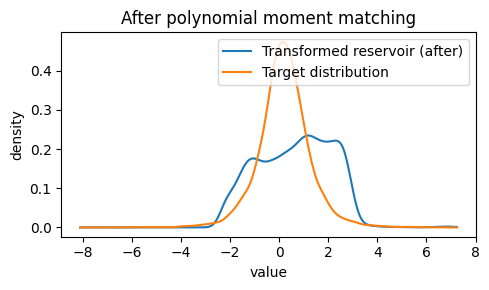

Optimized coefficients c* = [ 4.4348822e-03  1.0092016e+00  9.3175853e-03 -1.6275996e-02
  3.1583922e-03 -2.4010336e-05]

=== MOMENT COMPARISON ===
Mean (μ)       : Target=  0.1935, Reservoir=  0.5208, Matched=  0.6495
Variance (m2)  : Target=  1.1034, Reservoir=  3.1472, Matched=  2.2143
3rd moment (m3): Target=  0.0213, Reservoir= -4.1027, Matched= -0.0551
4th moment (m4): Target=  7.1654, Reservoir= 35.8557, Matched= 12.5639
5th moment (m5): Target= -0.4491, Reservoir=-108.8245, Matched= 16.5419
6th moment (m6): Target=112.5155, Reservoir=726.6689, Matched=184.5625

=== RELATIVE ERRORS ===
Mean (μ)       : Before=  1.6909, After=  2.3560, Improvement=  0.72x
Variance (m2)  : Before=  1.8523, After=  1.0068, Improvement=  1.84x
3rd moment (m3): Before=193.5338, After=  3.5863, Improvement= 53.97x
4th moment (m4): Before=  4.0040, After=  0.7534, Improvement=  5.31x
5th moment (m5): Before=241.3113, After= 37.8326, Improvement=  6.38x
6th moment (m6): Before=  5.4584, After=  0.6403, 

In [9]:

# -----------------------------
# 3) Define a 1D target and do moment matching with a cubic polynomial
# -----------------------------
def sample_target(key, n=8000, target_type="simple"):
    if target_type == "very_simple":
        # Very simple: just a scaled and shifted normal
        return jax.random.normal(key, (n,)) * 1.2 + 0.5
    elif target_type == "simple":
        # Simplified target: slightly skewed normal distribution
        # This is much more achievable for polynomial moment matching
        samples = jax.random.normal(key, (n,))
        # Add a small cubic nonlinearity to create some skewness and kurtosis
        samples = samples + 0.1 * samples**3
        # Scale and shift to desired range
        samples = 0.8 * samples + 0.2
        return samples
    else:  # "complex" - original mixture
        weights = jnp.array([0.5, 0.3, 0.2])
        means = jnp.array([-2.0, 0.5, 2.5])
        stds  = jnp.array([0.6, 0.5, 0.7])
        cats = jax.random.categorical(key, jnp.log(weights), shape=(n,))
        eps = jax.random.normal(key, (n,))
        return means[cats] + stds[cats] * eps

# Try the simple target first - change to "very_simple" if still having issues
target_samples = sample_target(jax.random.PRNGKey(123), n=8000, target_type="simple")

# Visualize the simplified target distribution
plt.figure(figsize=(6,3))
plt.hist(np.array(target_samples), bins=50, density=True, alpha=0.7, color='orange', label='Simplified target')
plt.title("Simplified Target Distribution")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

def kurtosis(x):
    x = x - jnp.mean(x)
    m2 = jnp.mean(x**2) + 1e-12
    m4 = jnp.mean(x**4)
    return m4 / (m2**2) - 3.0

k_stats = [kurtosis(p) for p in projections]
best_idx = int(jnp.argmax(jnp.abs(jnp.asarray(k_stats))))
s_res = projections[best_idx]

def central_moments(x):
    mu = jnp.mean(x)
    xc = x - mu
    m2 = jnp.mean(xc**2)
    m3 = jnp.mean(xc**3)
    m4 = jnp.mean(xc**4)
    m5 = jnp.mean(xc**5)  # 5th central moment
    m6 = jnp.mean(xc**6)  # 6th central moment
    return mu, m2, m3, m4, m5, m6

mu_t, m2_t, m3_t, m4_t, m5_t, m6_t = central_moments(target_samples)

def poly_transform(c, s):
    c0, c1, c2, c3, c4, c5 = c  # Now using quintic polynomial (degree 5)
    return c0 + c1*s + c2*(s**2) + c3*(s**3) + c4*(s**4) + c5*(s**5)

def loss_moments(c, s):
    y = poly_transform(c, s)
    mu, m2, m3, m4, m5, m6 = central_moments(y)
    # Normalize moments to improve numerical stability
    # Use progressively smaller weights for higher moments to prevent instability
    loss = ((mu - mu_t) / jnp.abs(mu_t + 1e-8))**2 + \
           ((m2 - m2_t) / jnp.abs(m2_t + 1e-8))**2 + \
           1e-2 * ((m3 - m3_t) / jnp.abs(m3_t + 1e-8))**2 + \
           1e-3 * ((m4 - m4_t) / jnp.abs(m4_t + 1e-8))**2 + \
           1e-4 * ((m5 - m5_t) / jnp.abs(m5_t + 1e-8))**2 + \
           1e-5 * ((m6 - m6_t) / jnp.abs(m6_t + 1e-8))**2
    return loss

grad_loss = jax.grad(loss_moments)

def optimize_moments(s, steps=3000, lr=5e-5):
    # Better initialization: start closer to identity but with small random perturbations
    key = jax.random.PRNGKey(42)
    c = jnp.array([0.0, 1.0, 0.0, 0.0, 0.0, 0.0]) + 0.01 * jax.random.normal(key, (6,))
    
    for i in range(steps):
        grad = grad_loss(c, s)
        
        # Gradient clipping to prevent explosion
        grad_norm = jnp.linalg.norm(grad)
        if grad_norm > 10.0:
            grad = grad * (10.0 / grad_norm)
        
        # Check for NaN gradients
        if jnp.any(jnp.isnan(grad)):
            print(f"NaN gradient at step {i}, stopping optimization")
            break
            
        # Adaptive learning rate
        current_lr = lr * (0.99 ** (i // 100))
        c = c - current_lr * grad
        
        # Check for NaN coefficients
        if jnp.any(jnp.isnan(c)):
            print(f"NaN coefficients at step {i}, stopping optimization")
            break
            
        # Print progress occasionally
        if i % 500 == 0:
            loss_val = loss_moments(c, s)
            print(f"Step {i}: loss = {loss_val:.6f}, coeffs = {c}")
    
    return c

print("Target moments (μ, m2, m3, m4, m5, m6):", mu_t, m2_t, m3_t, m4_t, m5_t, m6_t)
print("Reservoir projection moments:", *central_moments(s_res))

# Try the manual optimization first
c_opt = optimize_moments(s_res, steps=3000, lr=5e-6)

# If that fails, try a more robust approach with scipy-style optimization
if jnp.any(jnp.isnan(c_opt)):
    print("Manual optimization failed, trying robust approach...")
    
    def robust_loss(c, s):
        y = poly_transform(c, s)
        mu, m2, m3, m4, m5, m6 = central_moments(y)
        
        # Use relative errors with better scaling
        mu_err = (mu - mu_t)**2 / (mu_t**2 + 1.0)
        m2_err = (m2 - m2_t)**2 / (m2_t**2 + 1.0) 
        m3_err = (m3 - m3_t)**2 / (m3_t**2 + 1.0)
        m4_err = (m4 - m4_t)**2 / (m4_t**2 + 1.0)
        m5_err = (m5 - m5_t)**2 / (m5_t**2 + 1.0)
        m6_err = (m6 - m6_t)**2 / (m6_t**2 + 1.0)
        
        return mu_err + m2_err + 0.1*m3_err + 0.01*m4_err + 0.001*m5_err + 0.0001*m6_err
    
    # Use a simple grid search + local optimization
    best_loss = float('inf')
    best_c = jnp.array([0.0, 1.0, 0.0, 0.0, 0.0, 0.0])
    
    # Try several starting points
    for c0_init in [-1.0, 0.0, 1.0]:
        for c1_init in [0.5, 1.0, 1.5]:
            c_init = jnp.array([c0_init, c1_init, 0.0, 0.0, 0.0, 0.0])
            
            # Simple gradient descent with smaller steps
            c_current = c_init
            for step in range(1000):
                grad = jax.grad(robust_loss)(c_current, s_res)
                if jnp.any(jnp.isnan(grad)):
                    break
                c_current = c_current - 1e-5 * grad
                if jnp.any(jnp.isnan(c_current)):
                    break
            
            if not jnp.any(jnp.isnan(c_current)):
                loss_val = robust_loss(c_current, s_res)
                if loss_val < best_loss:
                    best_loss = loss_val
                    best_c = c_current
    
    c_opt = best_c
    print(f"Robust optimization result: loss = {best_loss:.6f}")

y_matched = poly_transform(c_opt, s_res)

# --- Figures: before/after ---
plt.figure(figsize=(5,3))
grid_c = jnp.linspace(jnp.minimum(jnp.min(s_res), jnp.min(target_samples))-1.0,
                      jnp.maximum(jnp.max(s_res), jnp.max(target_samples))+1.0, 400)
dens_res = kde_1d(s_res, grid_c)
dens_tar = kde_1d(target_samples, grid_c)
plt.plot(np.array(grid_c), np.array(dens_res), label="Reservoir projection (before)")
plt.plot(np.array(grid_c), np.array(dens_tar), label="Target distribution")
plt.title("Before moment matching"); plt.xlabel("value"); plt.ylabel("density"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(5,3))
dens_match = kde_1d(y_matched, grid_c)
plt.plot(np.array(grid_c), np.array(dens_match), label="Transformed reservoir (after)")
plt.plot(np.array(grid_c), np.array(dens_tar), label="Target distribution")
plt.title("After polynomial moment matching"); plt.xlabel("value"); plt.ylabel("density"); plt.legend(); plt.tight_layout(); plt.show()

print("Optimized coefficients c* =", c_opt)

# Compare all moments before and after transformation
print("\n=== MOMENT COMPARISON ===")
mu_res, m2_res, m3_res, m4_res, m5_res, m6_res = central_moments(s_res)
mu_match, m2_match, m3_match, m4_match, m5_match, m6_match = central_moments(y_matched)

moments_names = ["Mean (μ)", "Variance (m2)", "3rd moment (m3)", "4th moment (m4)", "5th moment (m5)", "6th moment (m6)"]
target_moments = [mu_t, m2_t, m3_t, m4_t, m5_t, m6_t]
reservoir_moments = [mu_res, m2_res, m3_res, m4_res, m5_res, m6_res]
matched_moments = [mu_match, m2_match, m3_match, m4_match, m5_match, m6_match]

for i, name in enumerate(moments_names):
    print(f"{name:15s}: Target={target_moments[i]:8.4f}, Reservoir={reservoir_moments[i]:8.4f}, Matched={matched_moments[i]:8.4f}")
    
# Calculate relative errors
print("\n=== RELATIVE ERRORS ===")
for i, name in enumerate(moments_names):
    if abs(target_moments[i]) > 1e-8:
        error_before = abs(reservoir_moments[i] - target_moments[i]) / abs(target_moments[i])
        error_after = abs(matched_moments[i] - target_moments[i]) / abs(target_moments[i])
        print(f"{name:15s}: Before={error_before:8.4f}, After={error_after:8.4f}, Improvement={error_before/max(error_after, 1e-8):6.2f}x")



---

### Exporting figures
- Each figure is shown inline; you can also save them (e.g., `plt.savefig("figure.png", dpi=300)`).
- For proposals: consider exporting the 2D scatter and a **3-panel** strip of marginals, plus before/after curves.

### Notes
- You can replace the target mixture with *any* 1D dataset, or change to sliced-cumulant/MMD objectives per your theory doc.
- Swap cubic for a richer readout (e.g., polynomial features or a small MLP) if you want flexibility beyond moments.
